(a) true=1.2566  MAP=3.0968  MMSE=1.6509
(b) true=1.2566  MAP=1.2635  MMSE=1.5773  gap=0.3138
SNR -10.0 dB   MAP 1.044e+00   MMSE 6.375e-01
SNR  -8.0 dB   MAP 7.069e-01   MMSE 4.649e-01
SNR  -6.0 dB   MAP 4.332e-01   MMSE 3.023e-01
SNR  -4.0 dB   MAP 1.748e-01   MMSE 1.233e-01
SNR  -2.0 dB   MAP 3.619e-02   MMSE 2.911e-02
SNR  +0.0 dB   MAP 9.369e-05   MMSE 1.546e-04
SNR  +2.0 dB   MAP 5.468e-05   MMSE 5.356e-05
SNR  +4.0 dB   MAP 3.589e-05   MMSE 3.509e-05
SNR  +6.0 dB   MAP 2.449e-05   MMSE 2.438e-05
SNR  +8.0 dB   MAP 1.542e-05   MMSE 1.504e-05
SNR +10.0 dB   MAP 8.643e-06   MMSE 8.565e-06


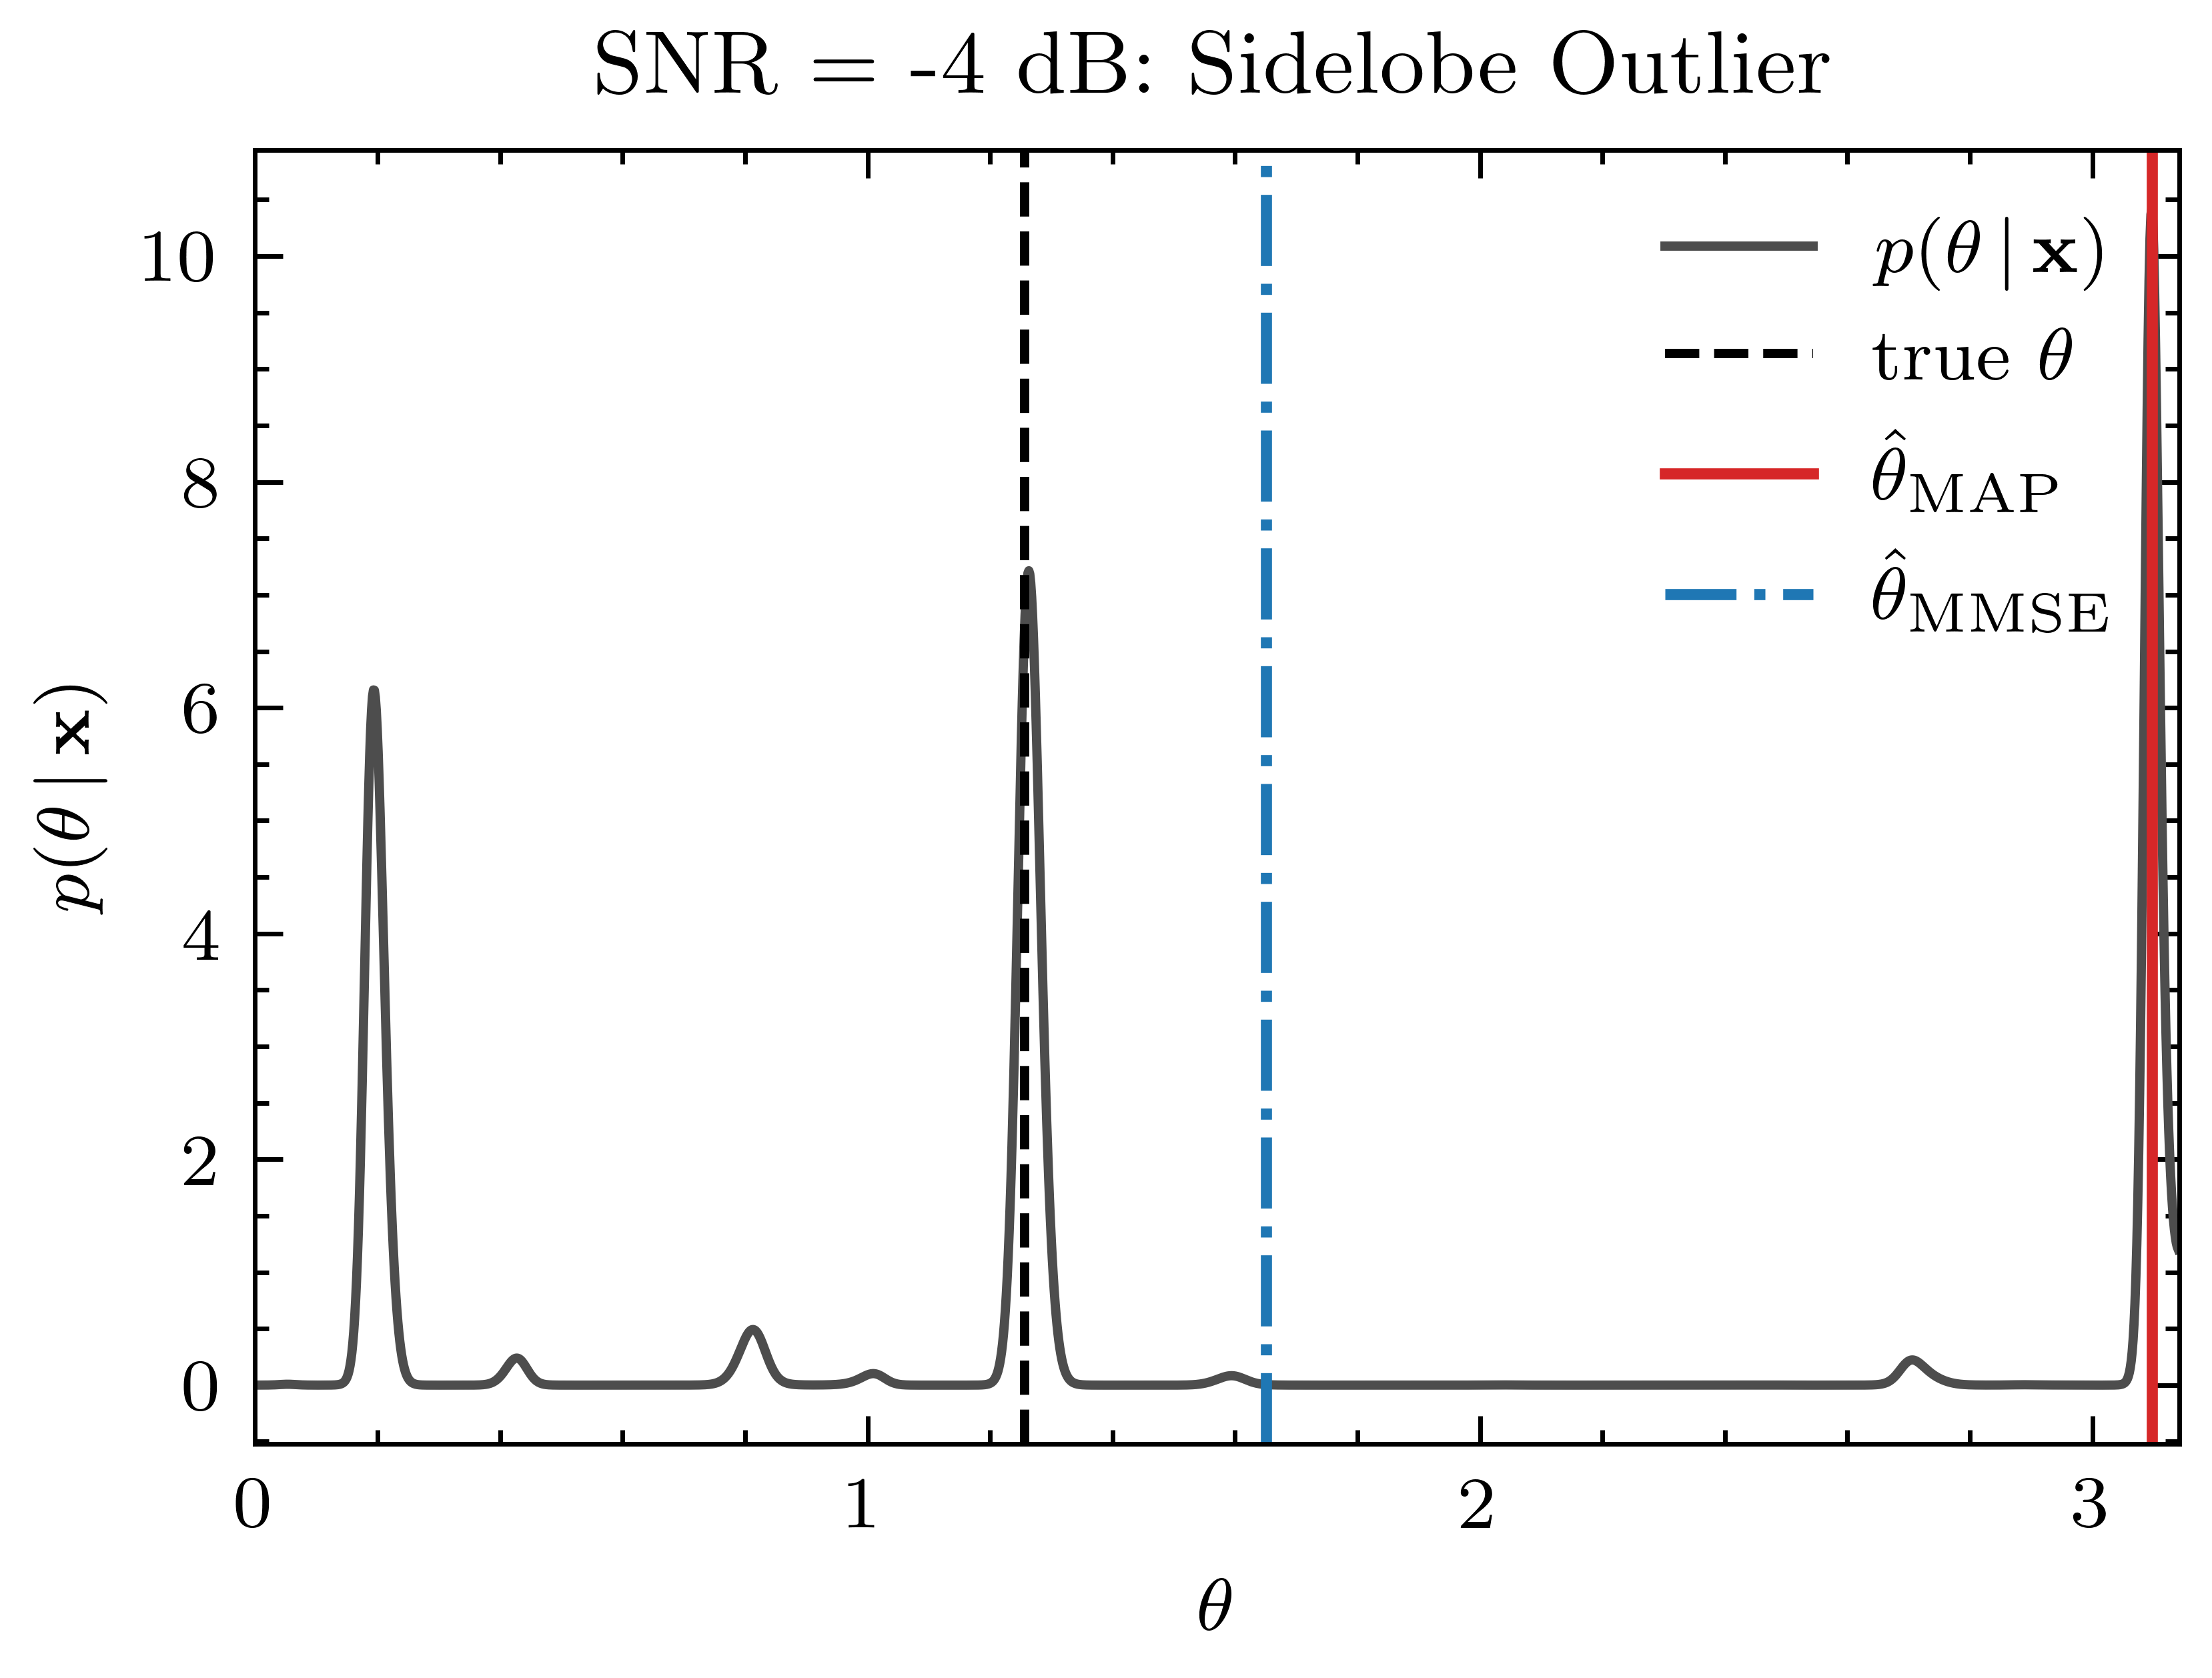

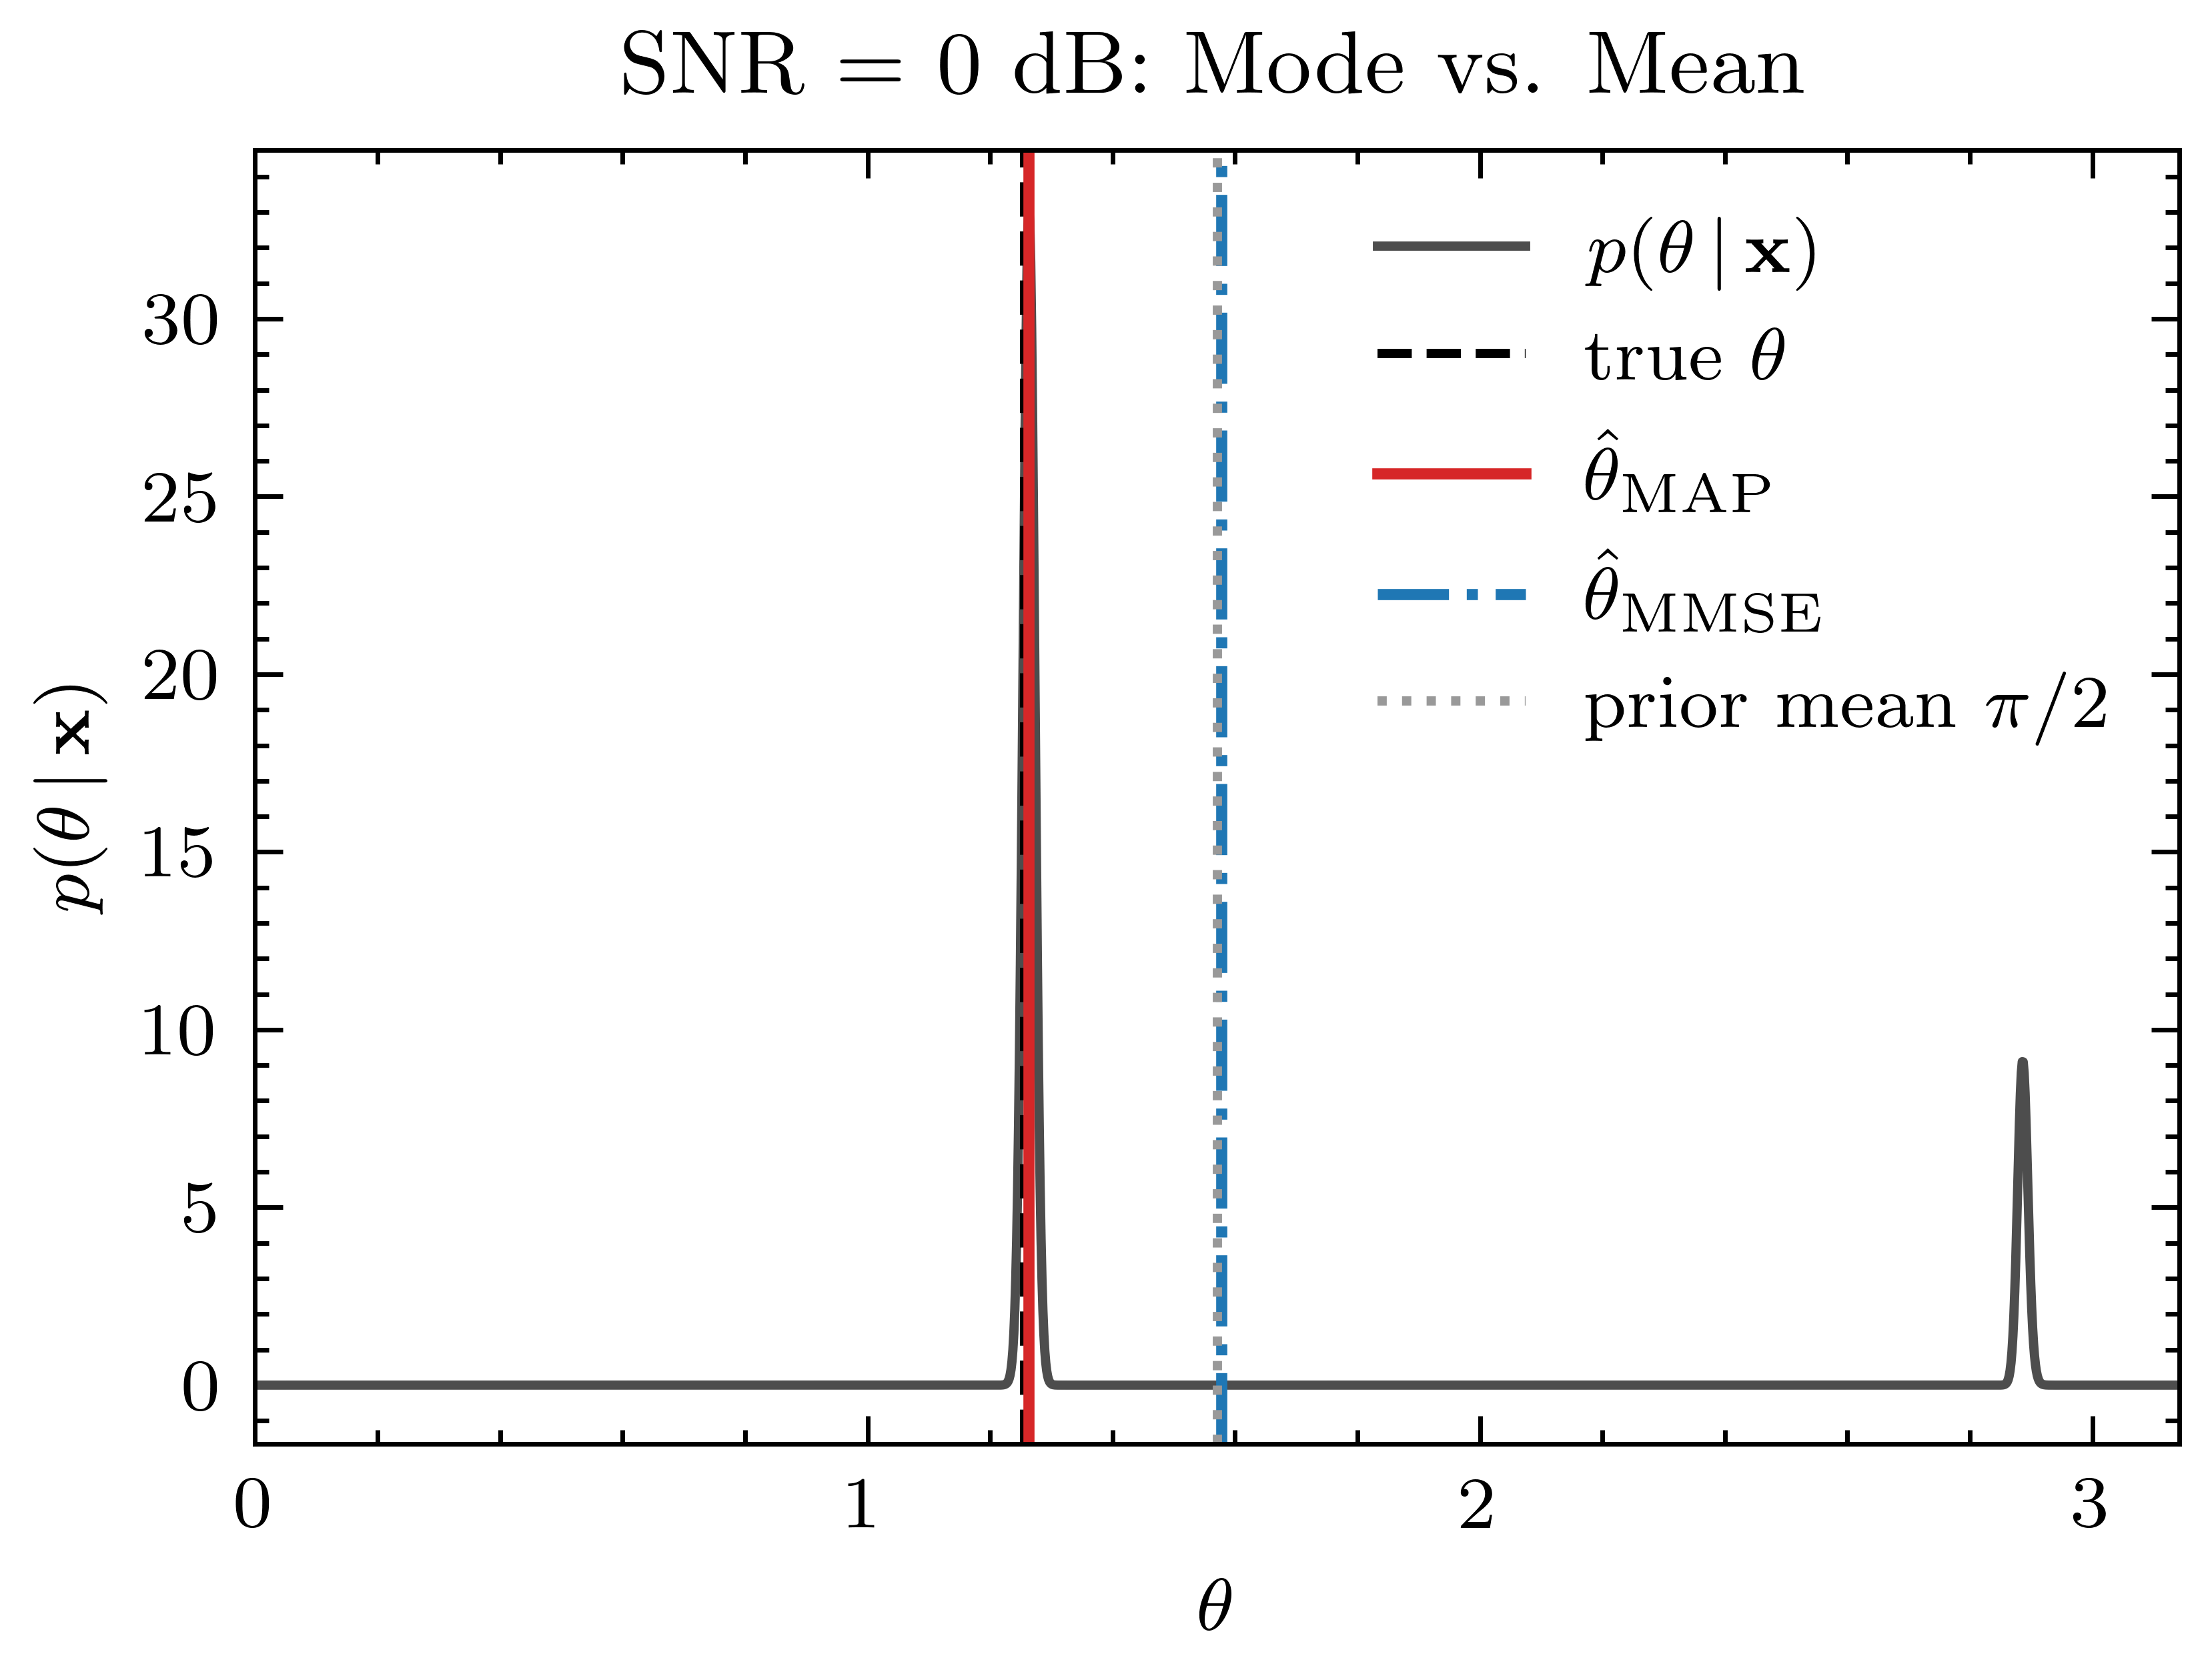

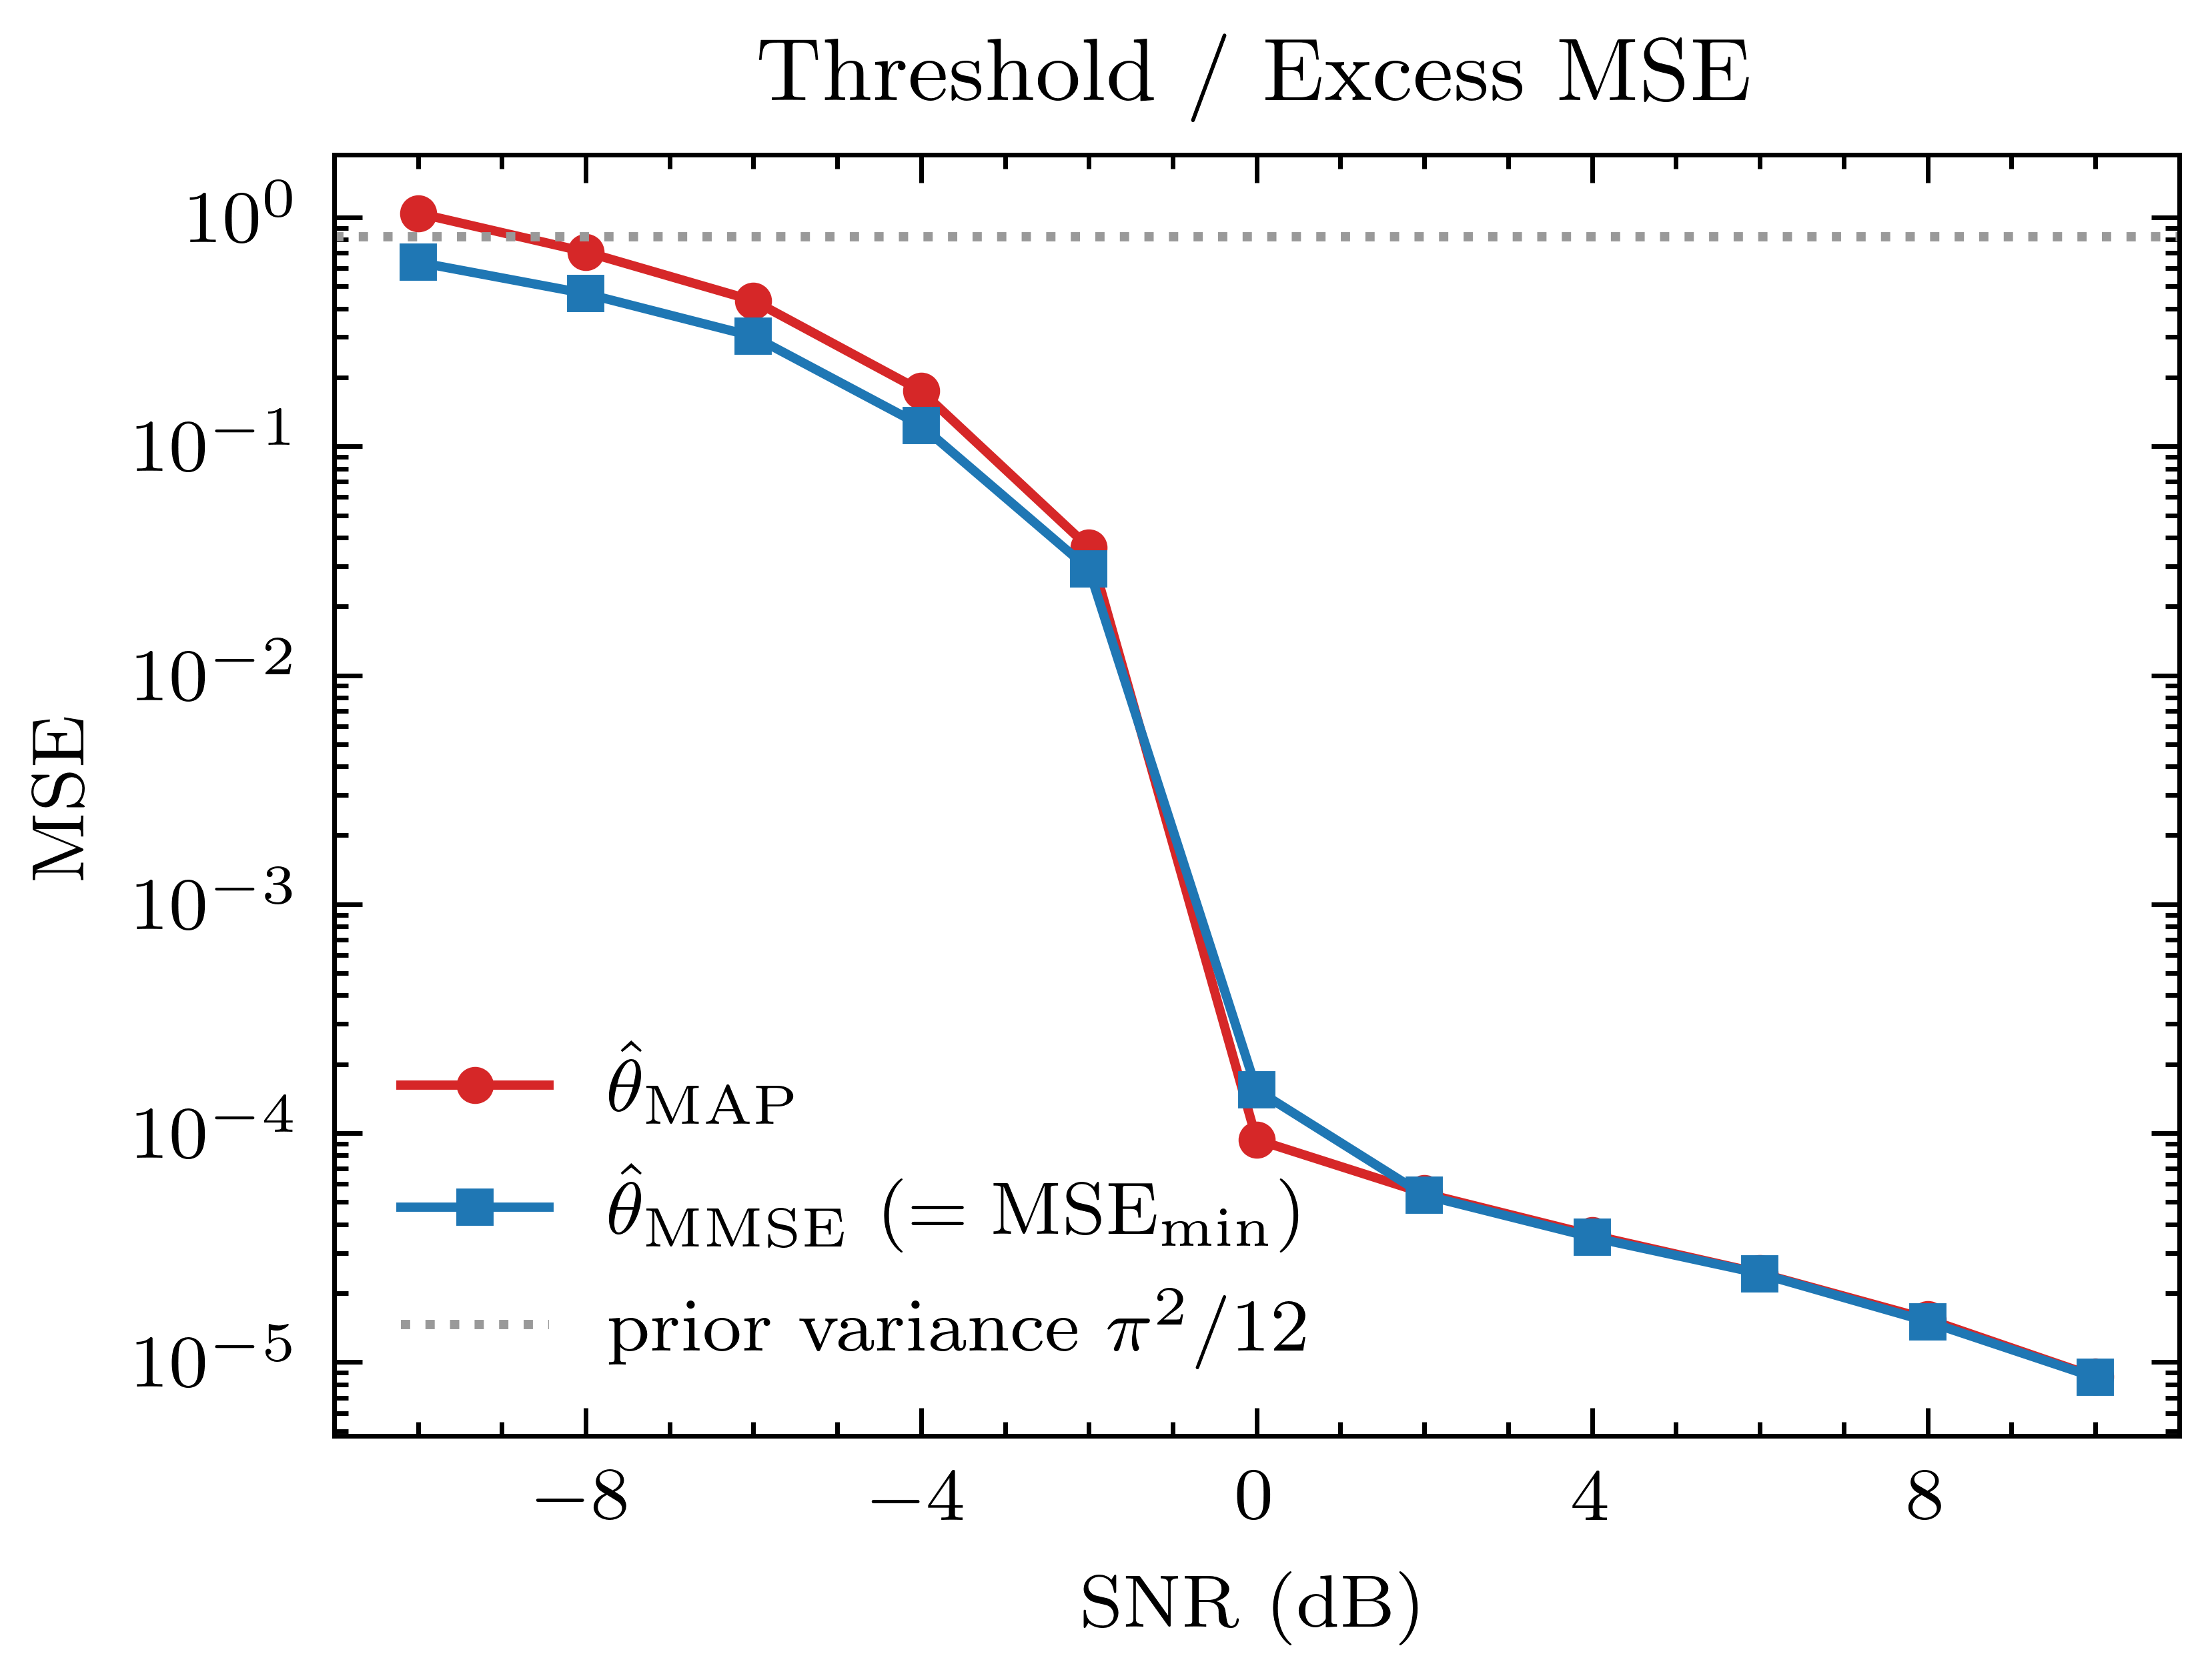

SNR  +2.0 dB   MAP 5.468e-05   MMSE 5.356e-05


SNR  +4.0 dB   MAP 3.589e-05   MMSE 3.509e-05


SNR  +6.0 dB   MAP 2.449e-05   MMSE 2.438e-05


SNR  +8.0 dB   MAP 1.542e-05   MMSE 1.504e-05


SNR +10.0 dB   MAP 8.643e-06   MMSE 8.565e-06


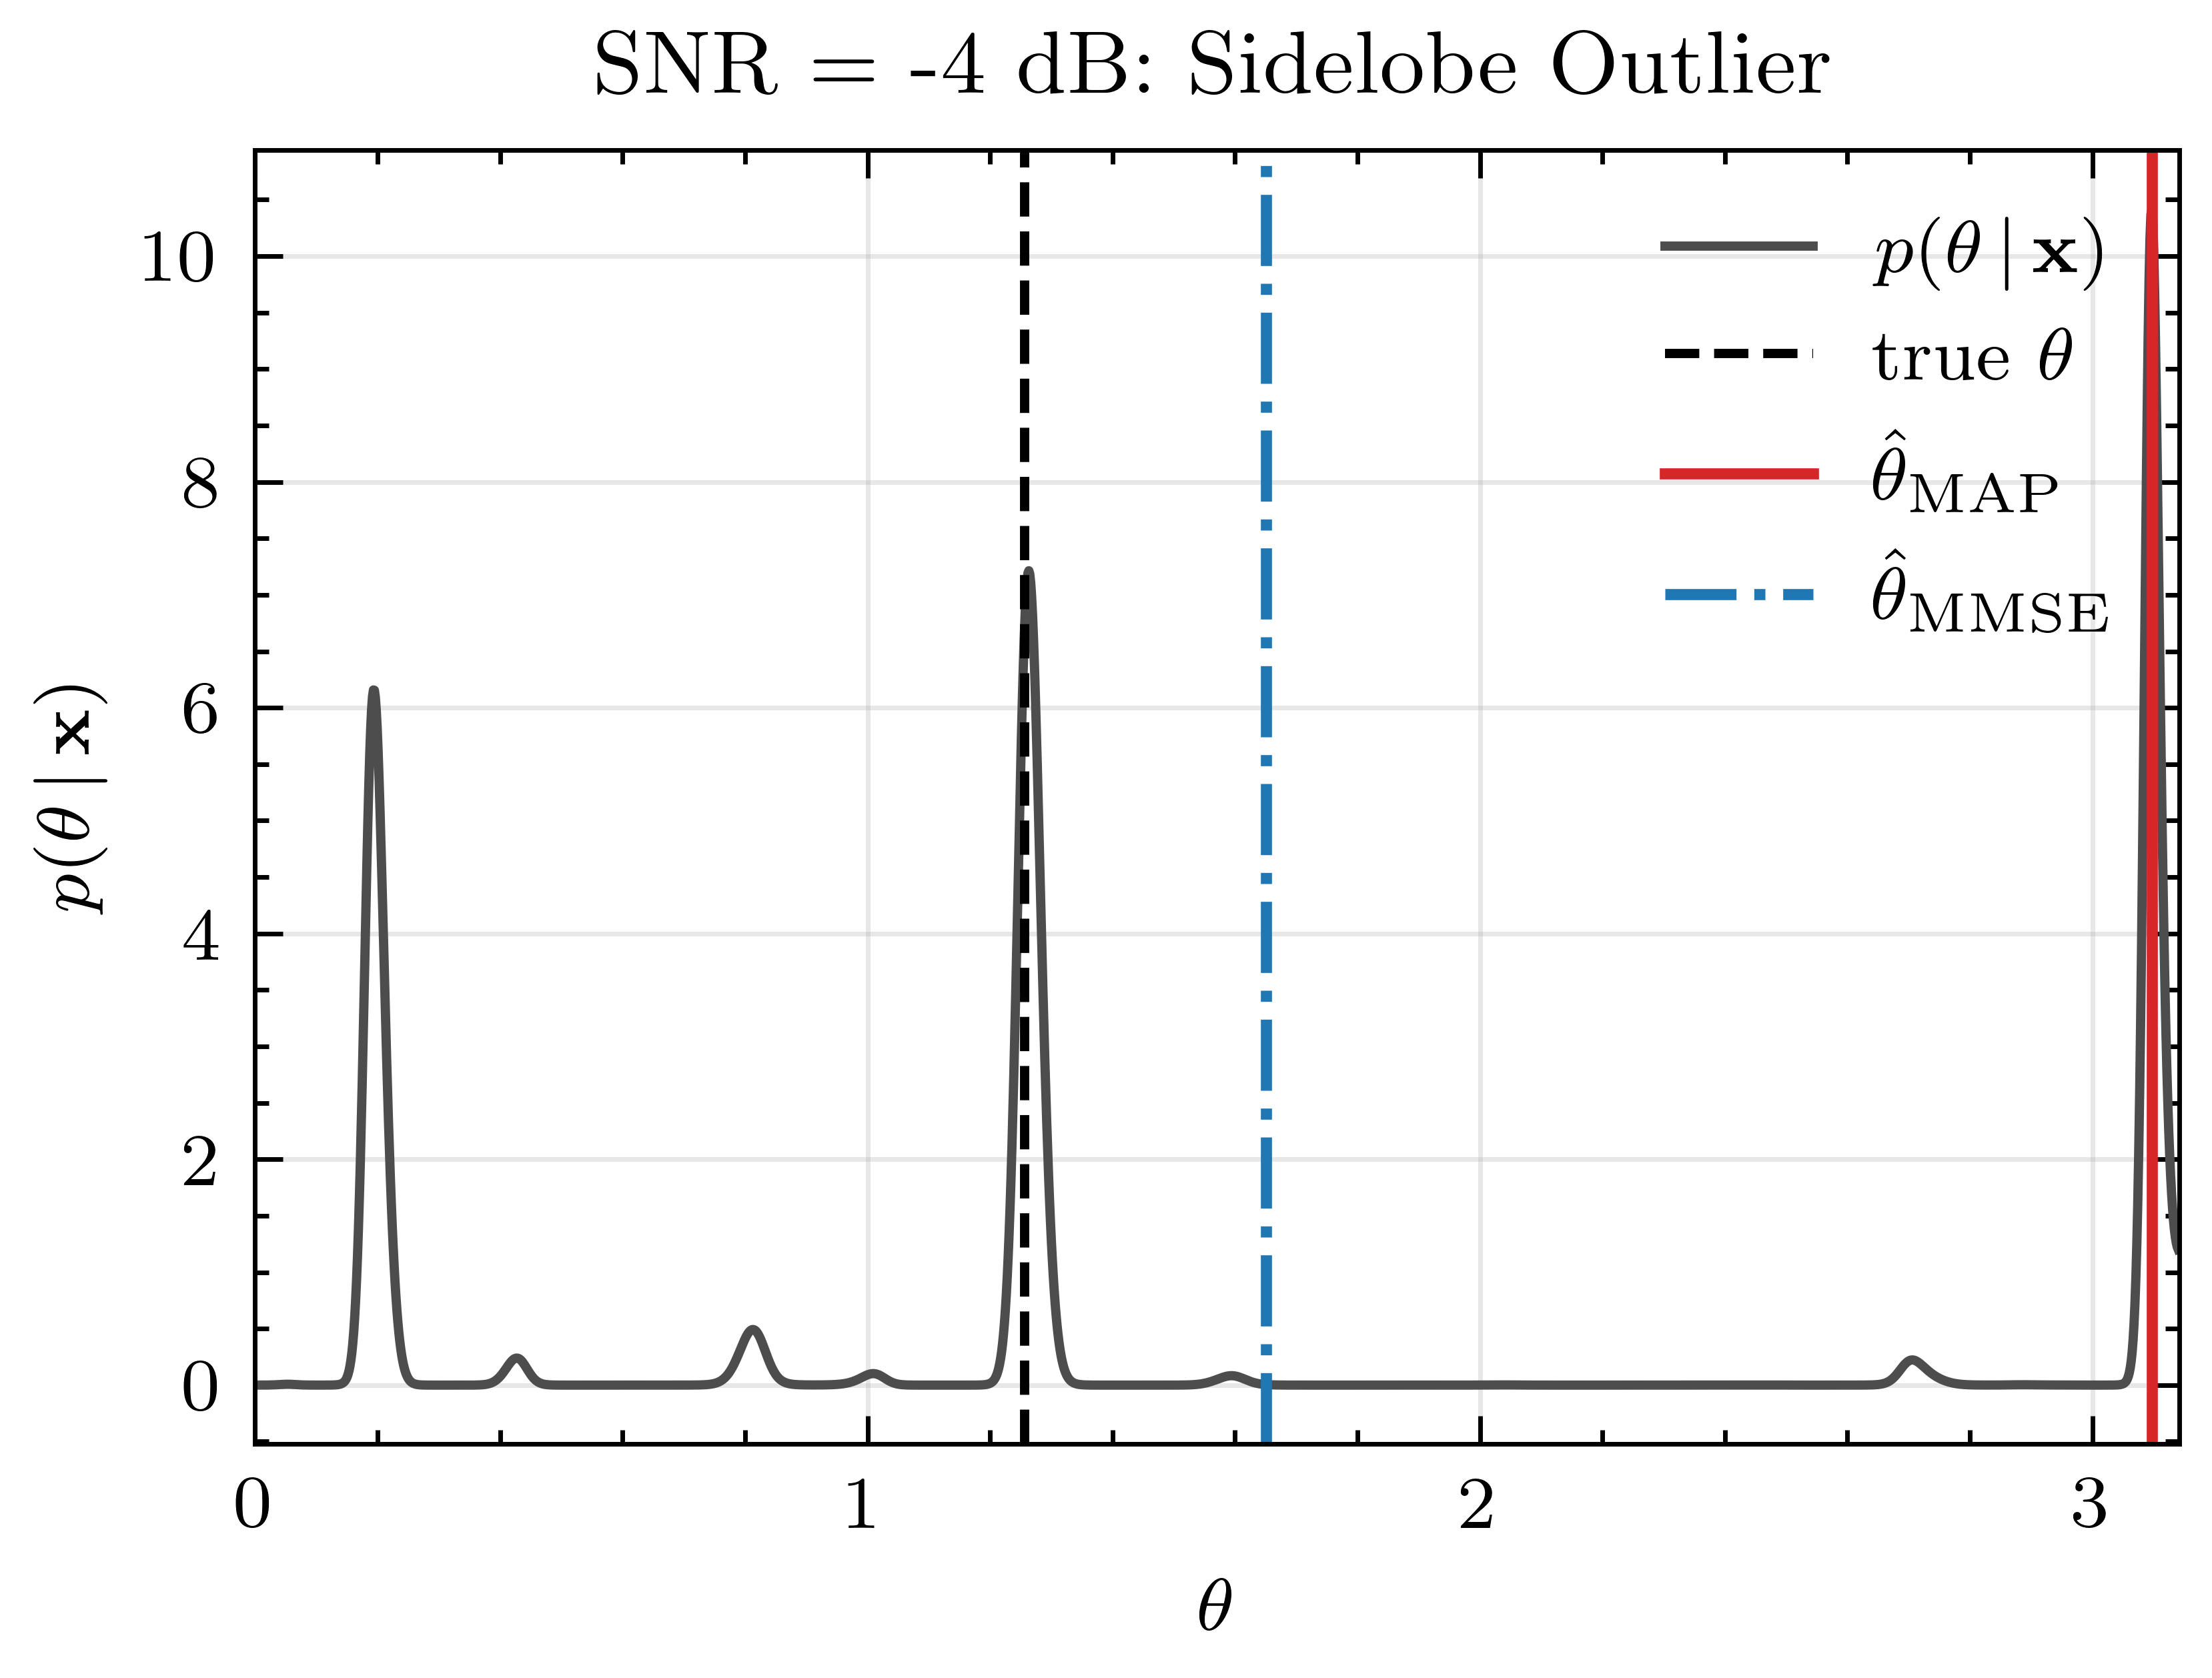

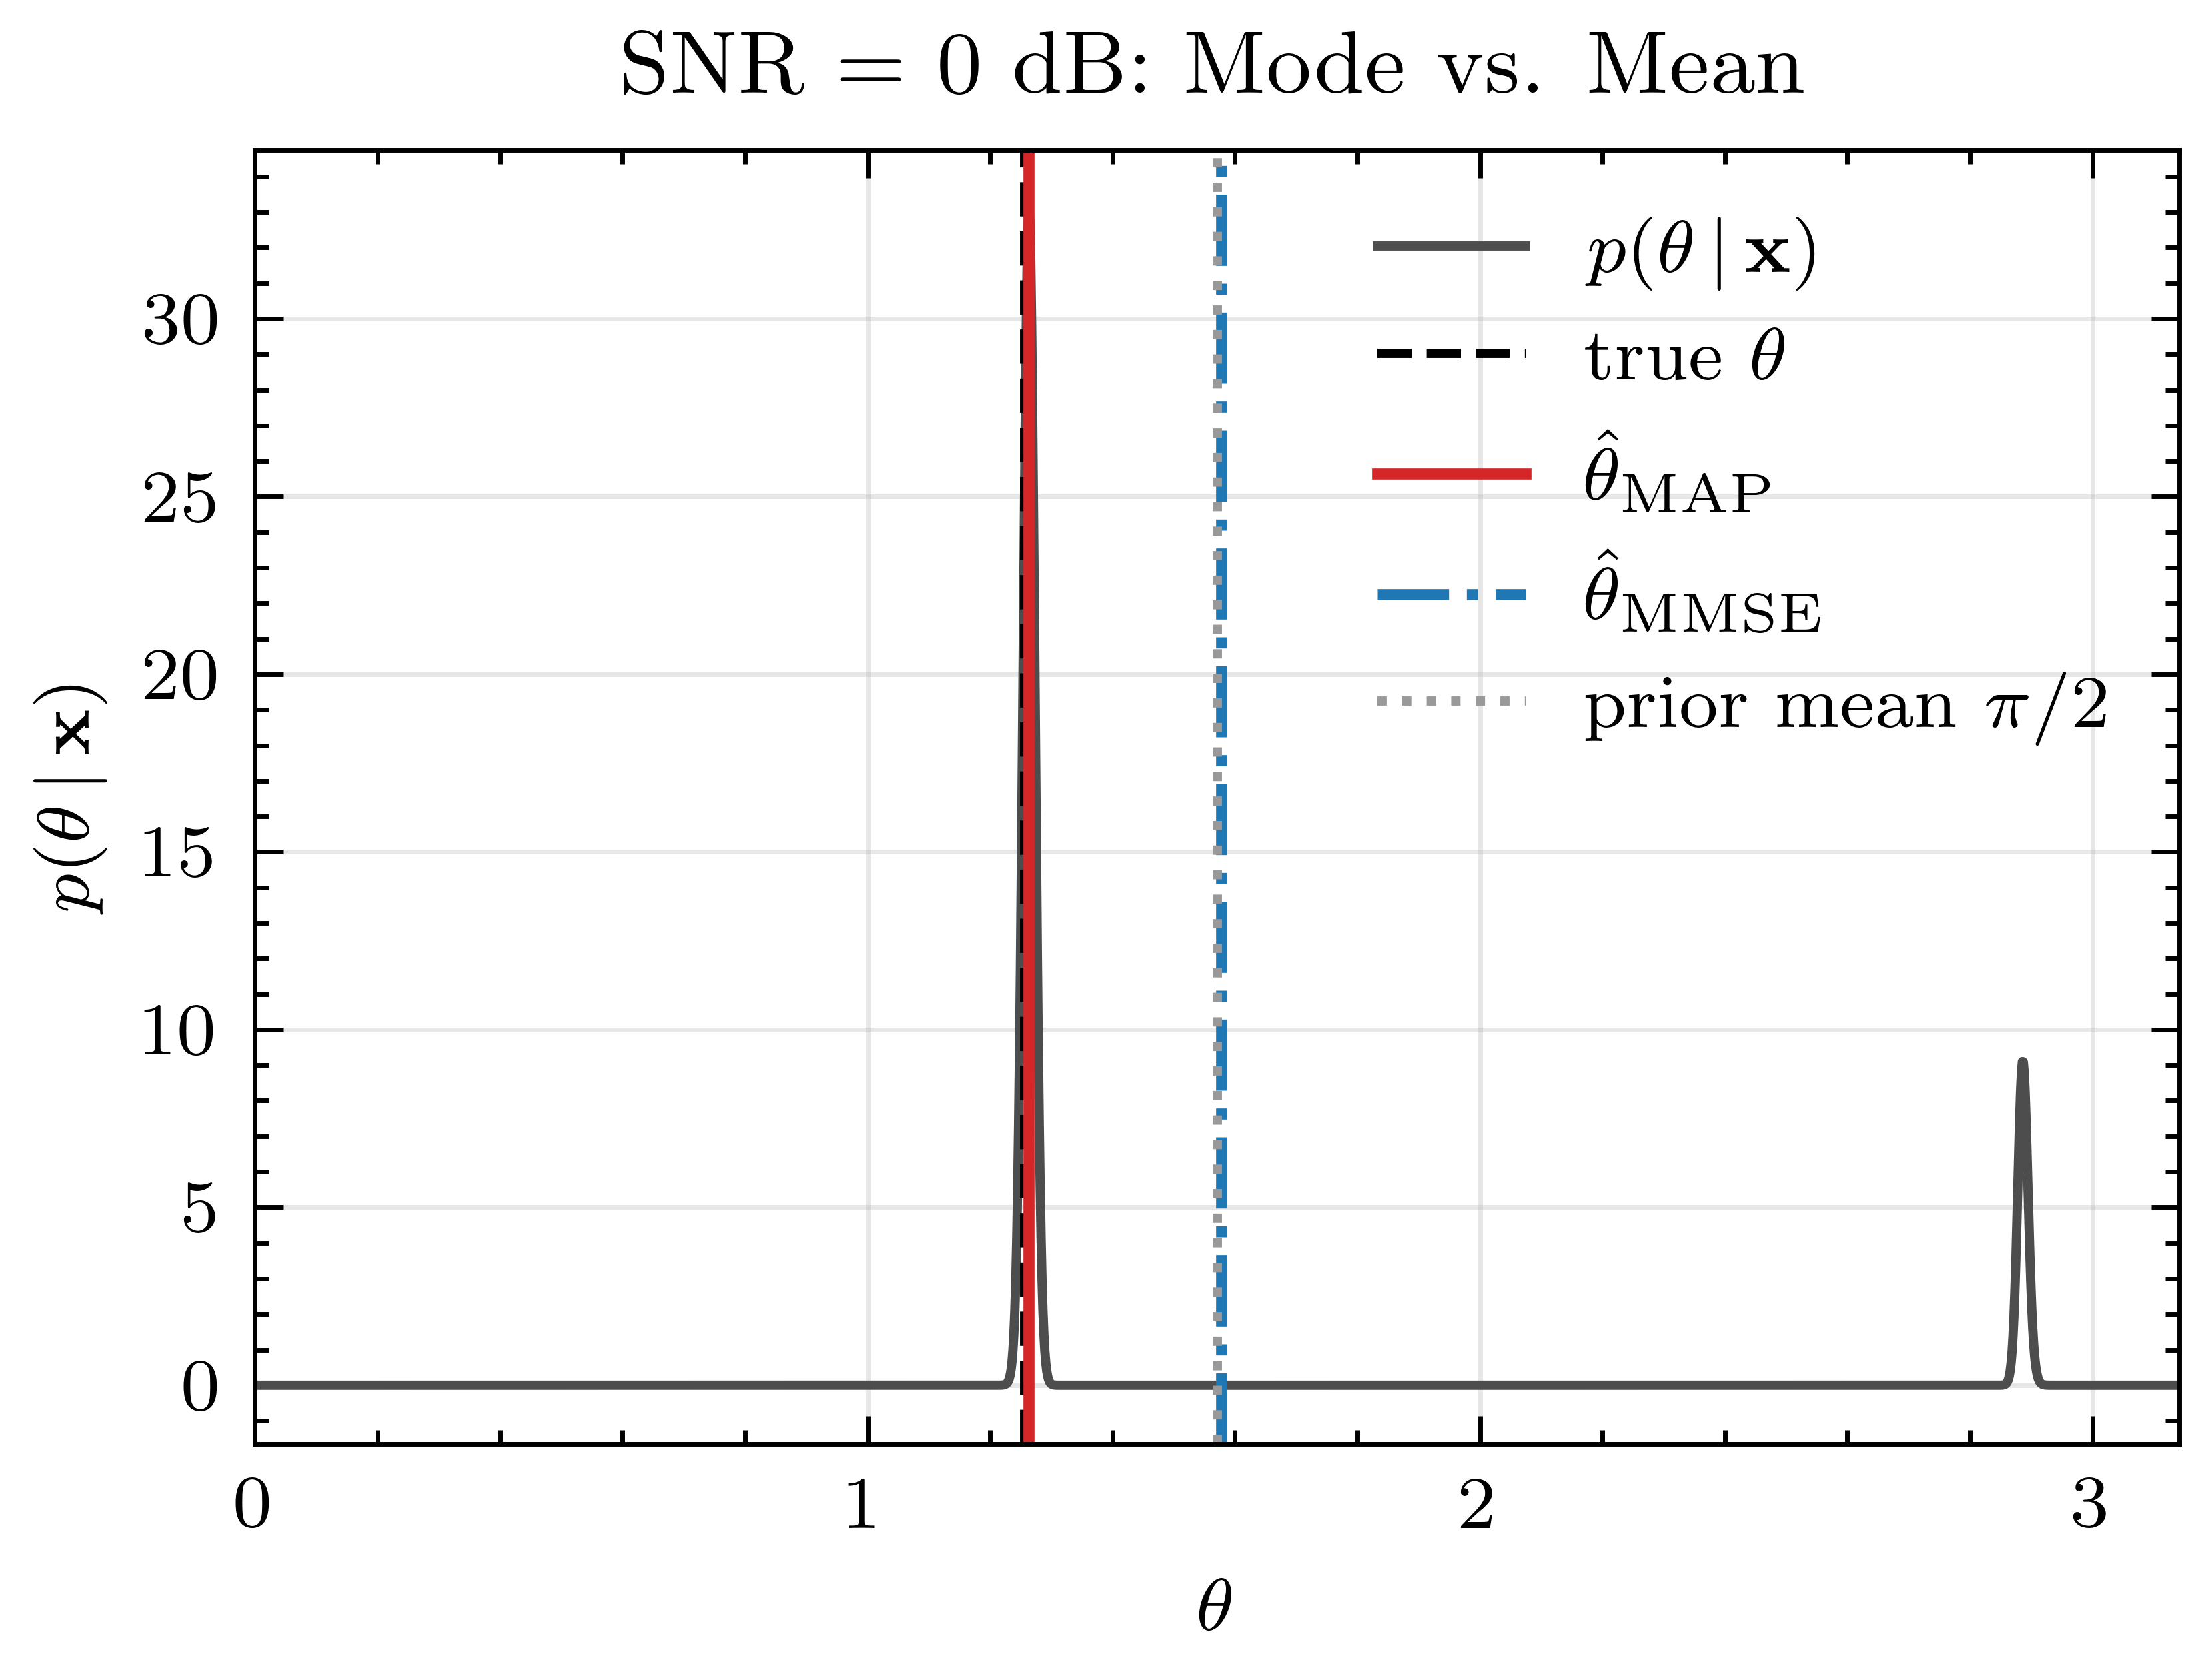

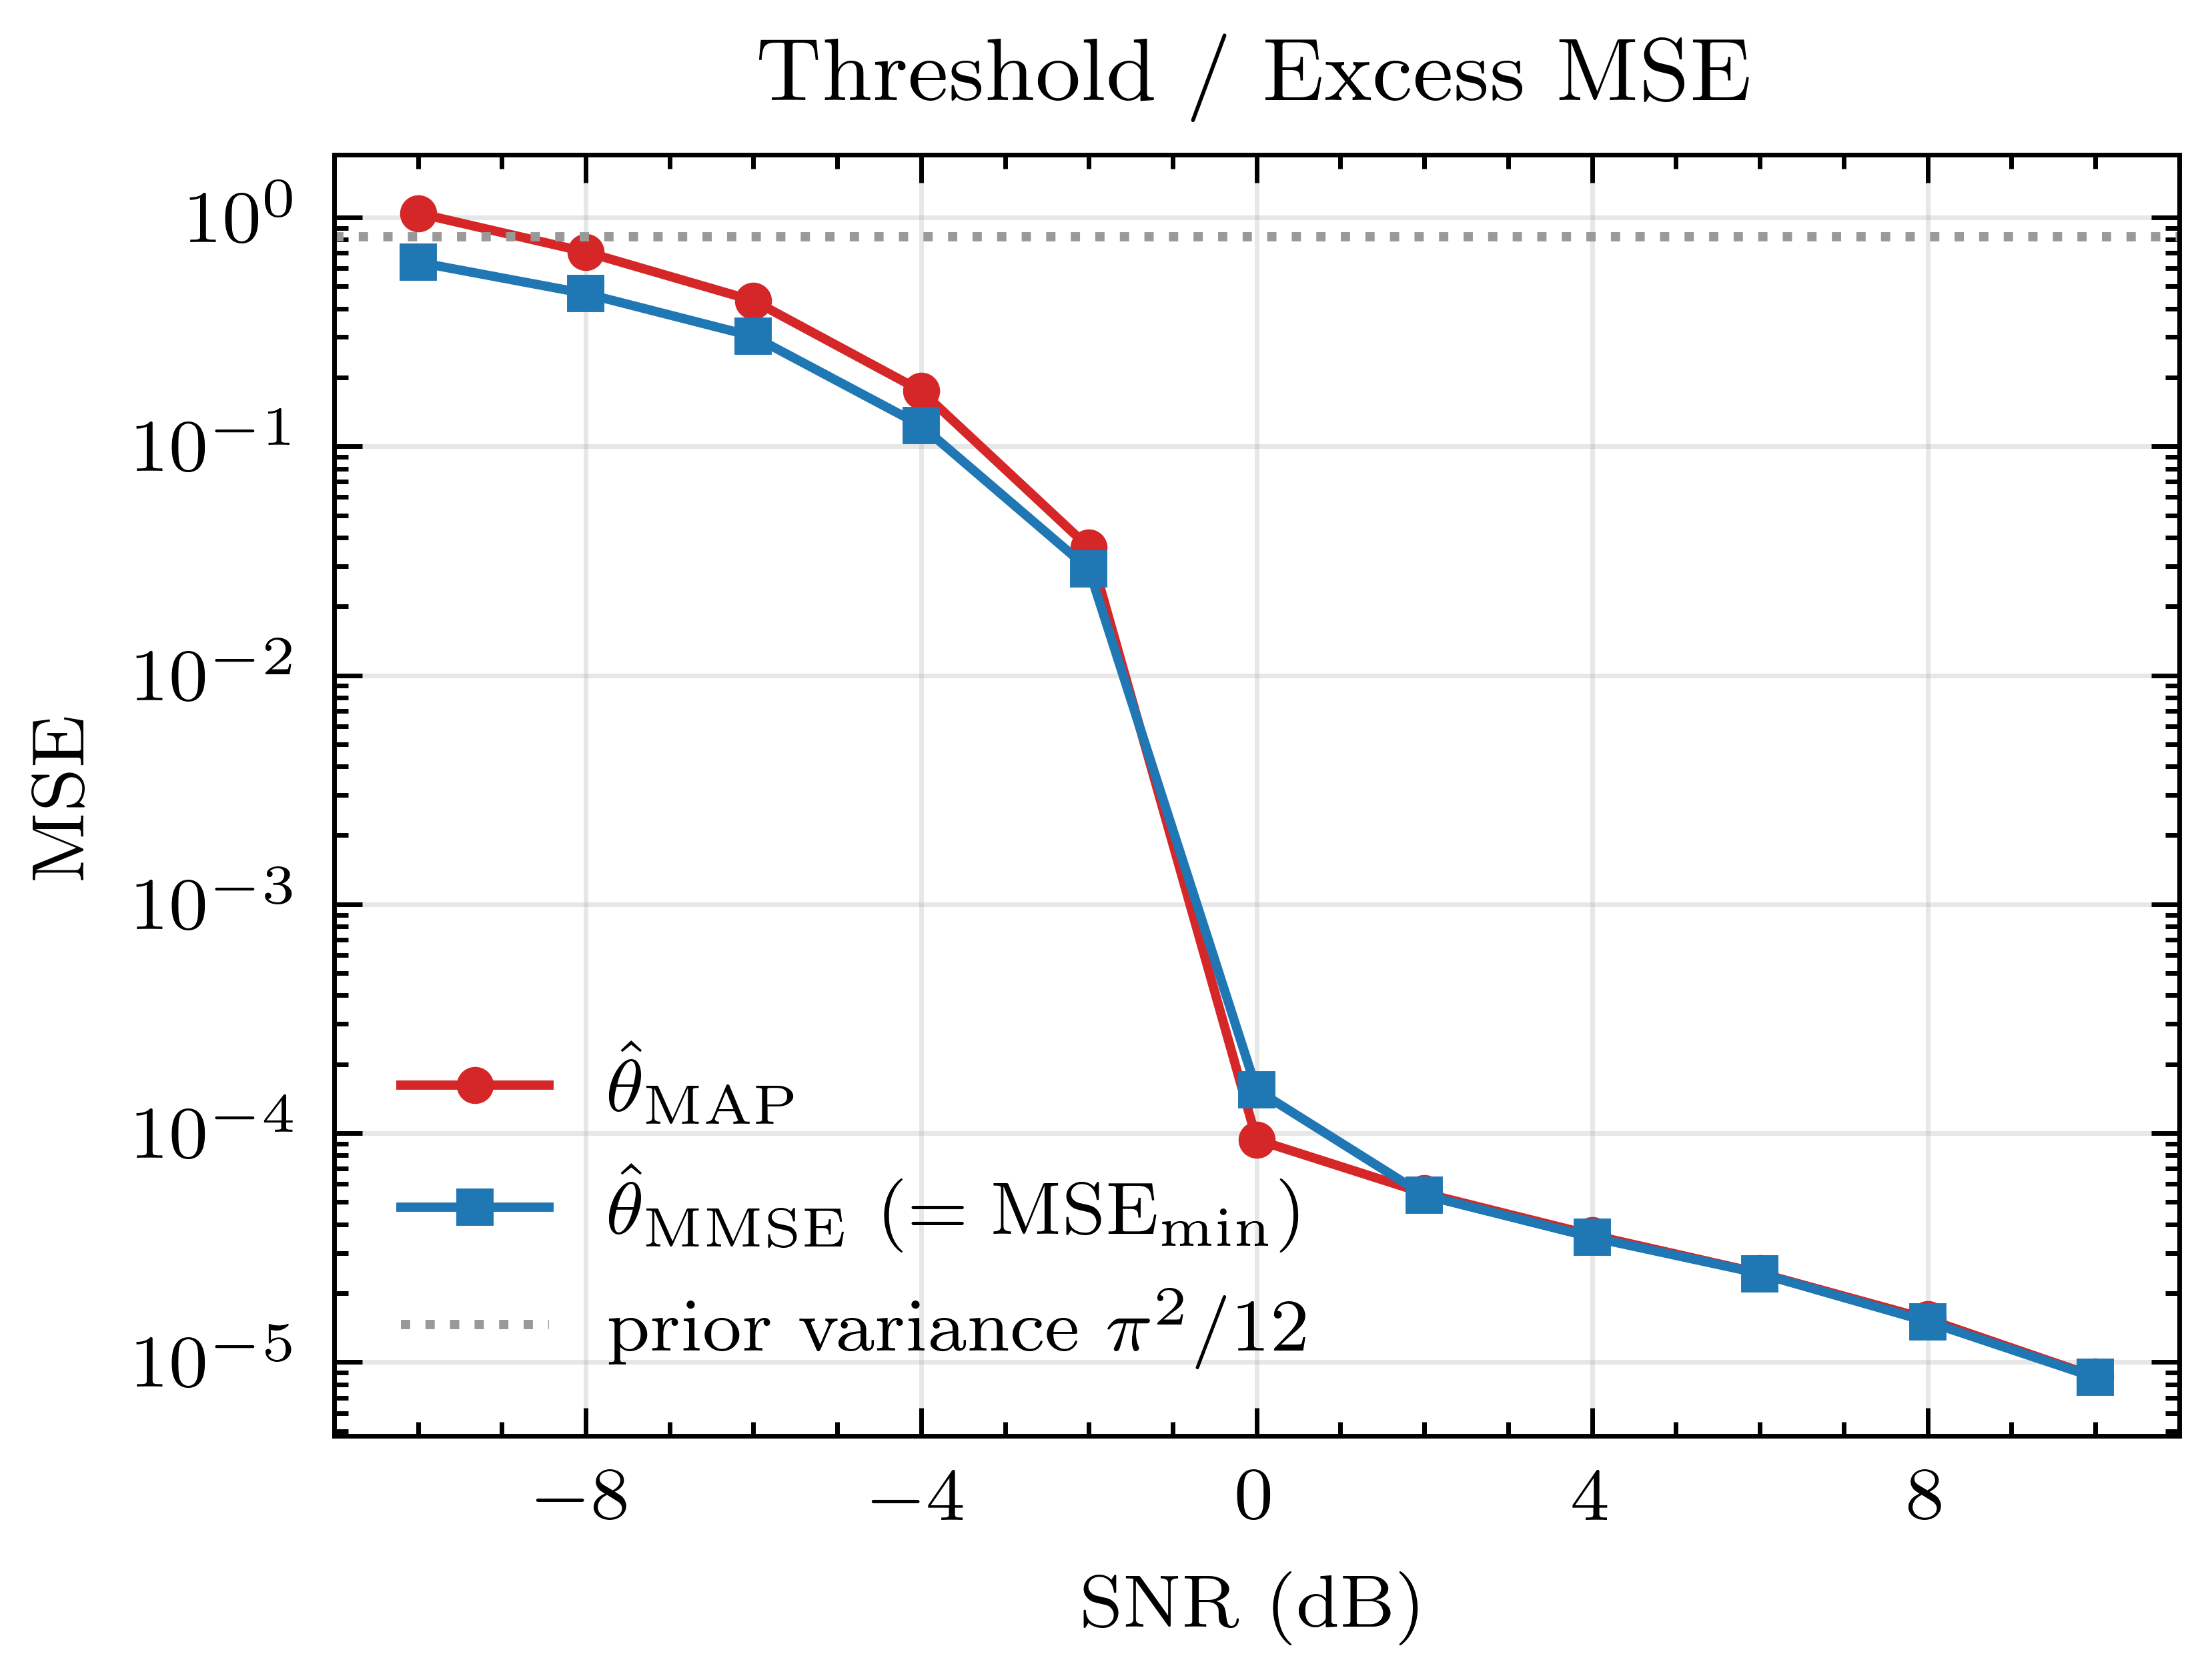

In [1]:
# %% [1] Setup: constants and a dense grid strictly inside (0, pi)
import math, torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
N = 32
n = torch.arange(1.0, N + 1.0)                      # n = 1,...,N
G = 2048
phi = torch.linspace(0.0, math.pi, G + 2)[1:-1]     # open interval (0, pi)
S = torch.cos(phi[:, None] * n)                     # (G, N), rows = s(phi)
s2 = (S**2).sum(dim=1)                              # ||s(phi)||^2
plt.rcParams.update({"font.size": 8, "axes.grid": False})

# %% [2] Model + the two estimators
def sigma_of(snr_db):                               # gamma = 1/(2 sigma_v^2)
    return math.sqrt(0.5 / 10 ** (snr_db / 10.0))

def sample_data(theta, snr_db, seed):               # x = cos(n*theta) + v,  theta: (T,)
    g = torch.Generator().manual_seed(seed)
    v = sigma_of(snr_db) * torch.randn(theta.numel(), N, generator=g)
    return torch.cos(theta[:, None] * n) + v

def posterior(x, snr_db):                           # p(phi|x) on grid, trapezoid-normalized
    lp = (2.0 * x @ S.T - s2) / (2.0 * sigma_of(snr_db) ** 2)
    p = torch.exp(lp - lp.max(dim=1, keepdim=True).values)
    return p / torch.trapezoid(p, phi, dim=1)[:, None]
    ##min --> max, trapezoid-normalized

def theta_mmse(x, snr_db):                          # Eq. (mmse) by quadrature
    return torch.trapezoid(phi * posterior(x, snr_db), phi, dim=1)

def H_fun(t, x):                                    # Eq. (stationary)
    nt = t[:, None] * n
    return (n * torch.sin(nt) * (x - torch.cos(nt))).sum(dim=1)

def D_fun(t, x):                                    # Eq. (curvature)
    nt = t[:, None] * n
    return (n**2 * (x * torch.cos(nt) - torch.cos(2.0 * nt))).sum(dim=1)

def theta_map(x, iters=6):                          # Eq. (grid) + safeguarded Eq. (newton)
    t = phi[(s2 - 2.0 * x @ S.T).argmin(dim=1)]
    for _ in range(iters):
        Hv, Dv = H_fun(t, x), D_fun(t, x)
        cand = t - Hv / Dv
        ok = (Dv > 0) & (cand > 0.0) & (cand < math.pi)
        t = torch.where(ok, cand, t)
    return t

# %% [3] Panel (a): low SNR -> MAP locks onto a sidelobe
snr_a, th_a = -4.0, 0.40 * math.pi
X = sample_data(torch.full((2000,), th_a), snr_a, seed=1)
m = theta_map(X)
i = (m - th_a).abs().argmax()  # most severe outlier in the batch
x_a = X[i:i+1]
map_a, mmse_a = m[i].item(), theta_mmse(x_a, snr_a).item()
post_a = posterior(x_a, snr_a)[0]
print(f"(a) true={th_a:.4f}  MAP={map_a:.4f}  MMSE={mmse_a:.4f}")

# %% [4] Panel (b): correct main lobe, but posterior mean != mode
snr_b, th_b = 0.0, 0.40 * math.pi
X = sample_data(torch.full((2000,), th_b), snr_b, seed=2)
m, mm = theta_map(X), theta_mmse(X, snr_b)
hit = (m - th_b).abs() < 0.5 * math.pi / N  # main lobe correctly resolved
gap = torch.where(hit, (mm - m).abs(), torch.zeros_like(m))
i = gap.argmax()
x_b = X[i:i+1]
map_b, mmse_b = m[i].item(), mm[i].item()
post_b = posterior(x_b, snr_b)[0]
print(f"(b) true={th_b:.4f}  MAP={map_b:.4f}  MMSE={mmse_b:.4f}  gap={gap[i].item():.4f}")

# %% [5] Panel (c): Monte-Carlo MSE vs SNR, theta ~ U(0, pi)
snr_grid = torch.arange(-10.0, 10.1, 2.0)
T = 2000
mse_map, mse_mmse = [], []
for k, s_db in enumerate(snr_grid.tolist()):
    th = math.pi * torch.rand(T, generator=torch.Generator().manual_seed(500 + k))
    ##T=2000 times true theta
    x = sample_data(th, s_db, seed=900 + k)
    mse_map.append(((theta_map(x) - th) ** 2).mean().item())
    mse_mmse.append(((theta_mmse(x, s_db) - th) ** 2).mean().item())
    print(f"SNR {s_db:+5.1f} dB   MAP {mse_map[-1]:.3e}   MMSE {mse_mmse[-1]:.3e}")

# %% [6] Assemble and save the figure
import math
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.ticker import MultipleLocator

# -------------------------------------------------------------------------
# 全局学术样式配置 (SciencePlots + IEEE 规范)
# -------------------------------------------------------------------------
plt.style.use(['science', 'ieee'])
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False

# 定义符合 IEEE 单栏论文的标准尺寸 (通常宽度在 3.3 到 3.5 英寸左右)
FIG_SIZE = (3.3, 2.5) 

# -------------------------------------------------------------------------
# 图 (a): 旁瓣异常锁定 (Sidelobe Outlier)
# -------------------------------------------------------------------------
fig_a, ax_a = plt.subplots(figsize=FIG_SIZE, constrained_layout=True)

ax_a.plot(phi.numpy(), post_a.numpy(), color="0.3", label=r"$p(\theta\,|\,\mathbf{x})$")
ax_a.axvline(th_a, ls="--", c="k", lw=1, label=r"true $\theta$")
ax_a.axvline(map_a, c="tab:red", lw=1.2, label=r"$\hat\theta_{\mathrm{MAP}}$")
ax_a.axvline(mmse_a, c="tab:blue", ls="-.", lw=1.2, label=r"$\hat\theta_{\mathrm{MMSE}}$")

ax_a.set(xlabel=r"$\theta$", ylabel=r"$p(\theta\,|\,\mathbf{x})$",
         title=f"SNR = {snr_a:g} dB: Sidelobe Outlier", xlim=(0, math.pi))

# 使用 MultipleLocator 设置 x 轴主刻度间隔为 1.0
ax_a.xaxis.set_major_locator(MultipleLocator(1.0))
ax_a.legend(loc="upper right")
plt.show()
#fig_a.savefig("fig_map_vs_mmse_a.pdf")
#plt.close(fig_a)

# -------------------------------------------------------------------------
# 图 (b): 众数 vs 均值 (Mode vs. Mean)
# -------------------------------------------------------------------------
fig_b, ax_b = plt.subplots(figsize=FIG_SIZE, constrained_layout=True)

ax_b.plot(phi.numpy(), post_b.numpy(), color="0.3", label=r"$p(\theta\,|\,\mathbf{x})$")
ax_b.axvline(th_b, ls="--", c="k", lw=1, label=r"true $\theta$")  # 已修正为 th_b
ax_b.axvline(map_b, c="tab:red", lw=1.2, label=r"$\hat\theta_{\mathrm{MAP}}$")
ax_b.axvline(mmse_b, c="tab:blue", ls="-.", lw=1.2, label=r"$\hat\theta_{\mathrm{MMSE}}$")
ax_b.axvline(math.pi / 2, ls=":", c="0.6", lw=1, label=r"prior mean $\pi/2$")

ax_b.set(xlabel=r"$\theta$", ylabel=r"$p(\theta\,|\,\mathbf{x})$",
         title=f"SNR = {snr_b:g} dB: Mode vs. Mean", xlim=(0, math.pi))

ax_b.xaxis.set_major_locator(MultipleLocator(1.0))
ax_b.legend(loc="upper right")
plt.show()
#fig_b.savefig("fig_map_vs_mmse_b.pdf")
#plt.close(fig_b)

# -------------------------------------------------------------------------
# 图 (c): 均方误差性能曲线 (Threshold / Excess MSE)
# -------------------------------------------------------------------------
fig_c, ax_c = plt.subplots(figsize=FIG_SIZE, constrained_layout=True)

ax_c.semilogy(snr_grid.numpy(), mse_map, "o-", c="tab:red", lw=1, markersize=3,
             label=r"$\hat\theta_{\mathrm{MAP}}$")
ax_c.semilogy(snr_grid.numpy(), mse_mmse, "s-", c="tab:blue", lw=1, markersize=3,
             label=r"$\hat\theta_{\mathrm{MMSE}}\ (=\mathrm{MSE}_{\min})$")
ax_c.axhline(math.pi**2 / 12, ls=":", c="0.6", lw=1,
            label=r"prior variance $\pi^{2}/12$")

ax_c.set(xlabel="SNR (dB)", ylabel="MSE", title="Threshold / Excess MSE")

# 设置 SNR 轴的刻度间隔为 4.0 dB
ax_c.xaxis.set_major_locator(MultipleLocator(4.0))
ax_c.legend(loc="lower left")
plt.show()
#fig_c.savefig("fig_map_vs_mmse_c.pdf")

In [3]:
# %% [3b] Noise-enhanced estimate for the panel-(a) realization, Eq. (theta_ne)
# Illustrative choice q(z) = N(0, sigma_z^2 I); the optimal design of q is the
# subject of the following sections.
sigma_z = 1.0 * sigma_of(snr_a)                     # artificial-noise level (tunable)
L = 4000                                            # Monte-Carlo samples for E_z[.]
gz = torch.Generator().manual_seed(7)
Z = sigma_z * torch.randn(L, N, generator=gz)
##For N samples generating L=4000 z_k
th_pert = theta_map(x_a + Z)                        # MAP estimates of perturbed data
ne_a = th_pert.mean().item()
print(f"(a) NE={ne_a:.4f}  (sigma_z = sigma_v, L={L}, "
      f"MC-SE={th_pert.std().item()/math.sqrt(L):.4f})")
print(f"    |MAP-true|={abs(map_a-th_a):.3f}   |NE-true|={abs(ne_a-th_a):.3f}   "
      f"|NE-MMSE|={abs(ne_a-mmse_a):.3f}")

# sensitivity of the NE estimate to the artificial-noise level
for c in [0.5, 1.0, 1.5, 2.0]:
    gz = torch.Generator().manual_seed(7)
    tp = theta_map(x_a + c * sigma_of(snr_a) * torch.randn(L, N, generator=gz))
    print(f"    sigma_z={c:3.1f}*sigma_v  ->  NE={tp.mean().item():.4f}")

(a) NE=1.5420  (sigma_z = sigma_v, L=4000, MC-SE=0.0179)
    |MAP-true|=1.840   |NE-true|=0.285   |NE-MMSE|=0.109
    sigma_z=0.5*sigma_v  ->  NE=1.6829
    sigma_z=1.0*sigma_v  ->  NE=1.5420
    sigma_z=1.5*sigma_v  ->  NE=1.5145
    sigma_z=2.0*sigma_v  ->  NE=1.5207


    sigma_z=2.0*sigma_v  ->  NE=1.5207


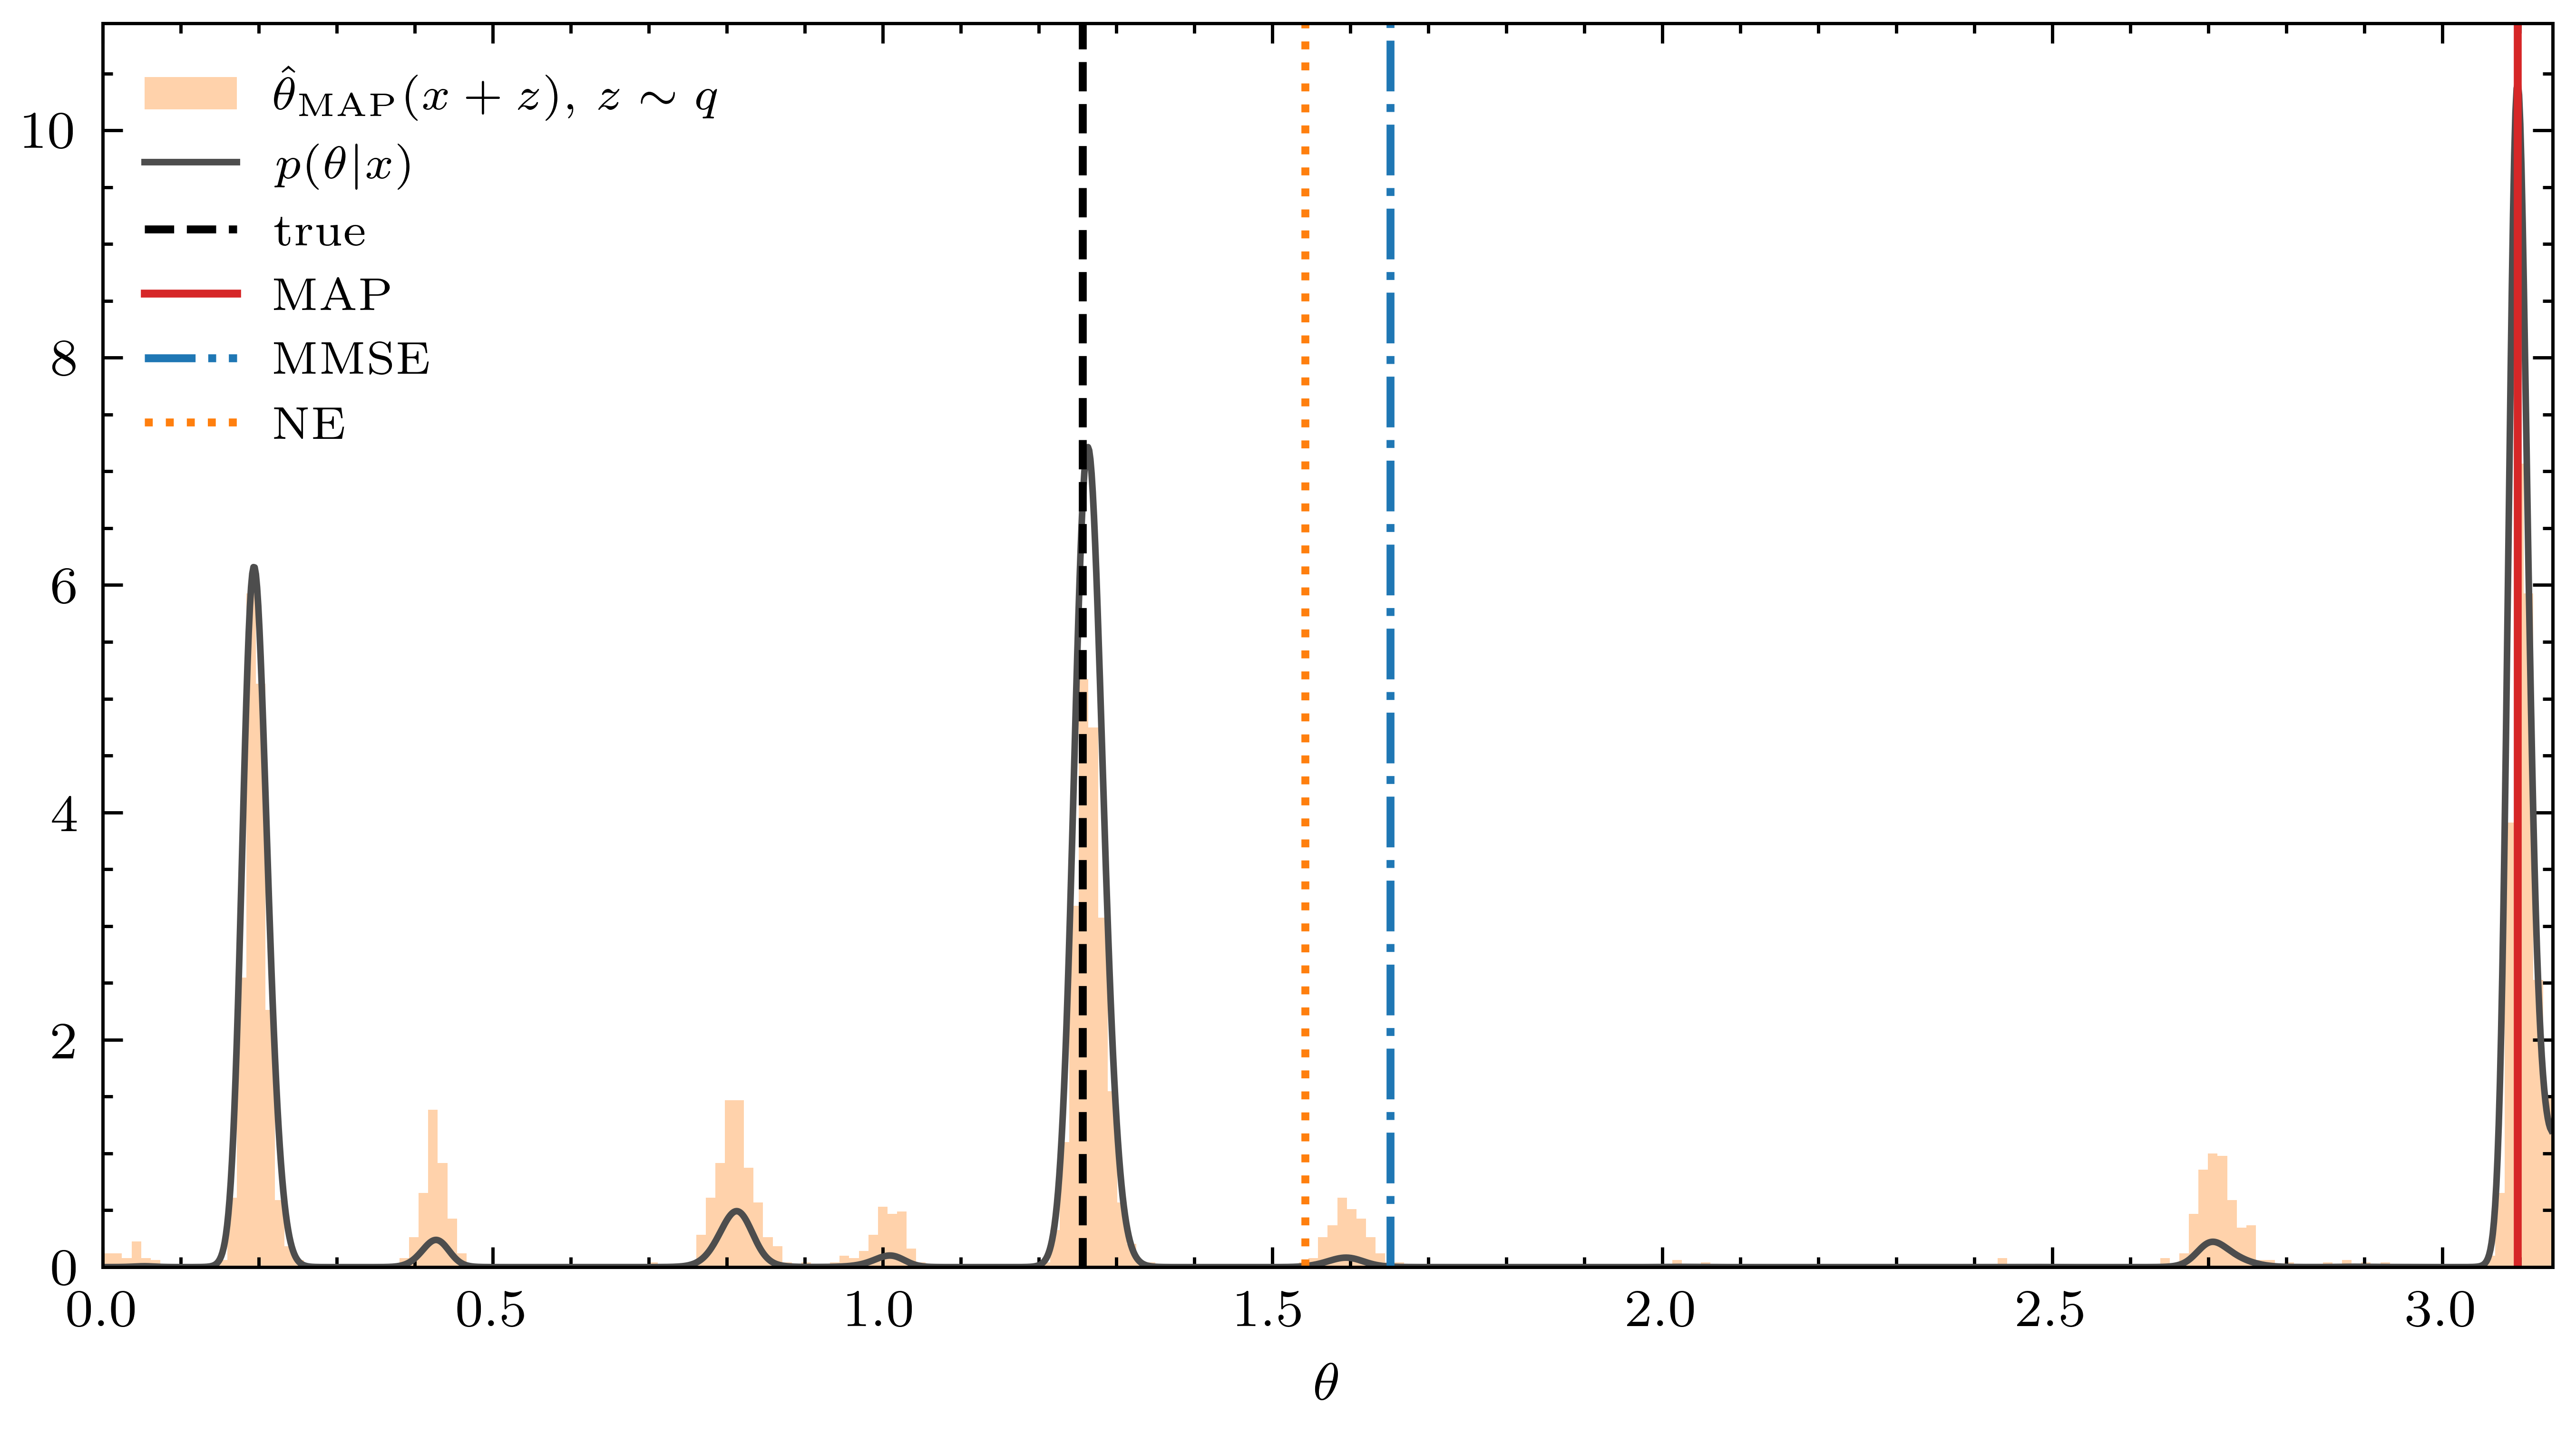

In [4]:
# %% [3c] Diagnostic (not for the paper): what the NE estimator averages.
# The distribution of theta_MAP(x+z) hedges across the posterior lobes, so its
# mean (= theta_NE) mimics the posterior-mean hedging of theta_MMSE.
fig_d, ax_d = plt.subplots(figsize=(5.4, 3.0), constrained_layout=True)
ax_d.hist(th_pert.numpy(), bins=256, range=(0.0, math.pi), density=True,
          color="tab:orange", alpha=0.35,
          label=r"$\hat\theta_{\mathrm{MAP}}(x+z)$, $z\sim q$")
ax_d.plot(phi.numpy(), post_a.numpy(), color="0.3", label=r"$p(\theta|x)$")
for val, c, ls, lab in [(th_a, "k", "--", "true"), (map_a, "tab:red", "-", "MAP"),
                        (mmse_a, "tab:blue", "-.", "MMSE"),
                        (ne_a, "tab:orange", ":", "NE")]:
    ax_d.axvline(val, c=c, ls=ls, lw=1.2, label=lab)
ax_d.set(xlabel=r"$\theta$", xlim=(0, math.pi))
ax_d.legend(fontsize=7)
plt.show()

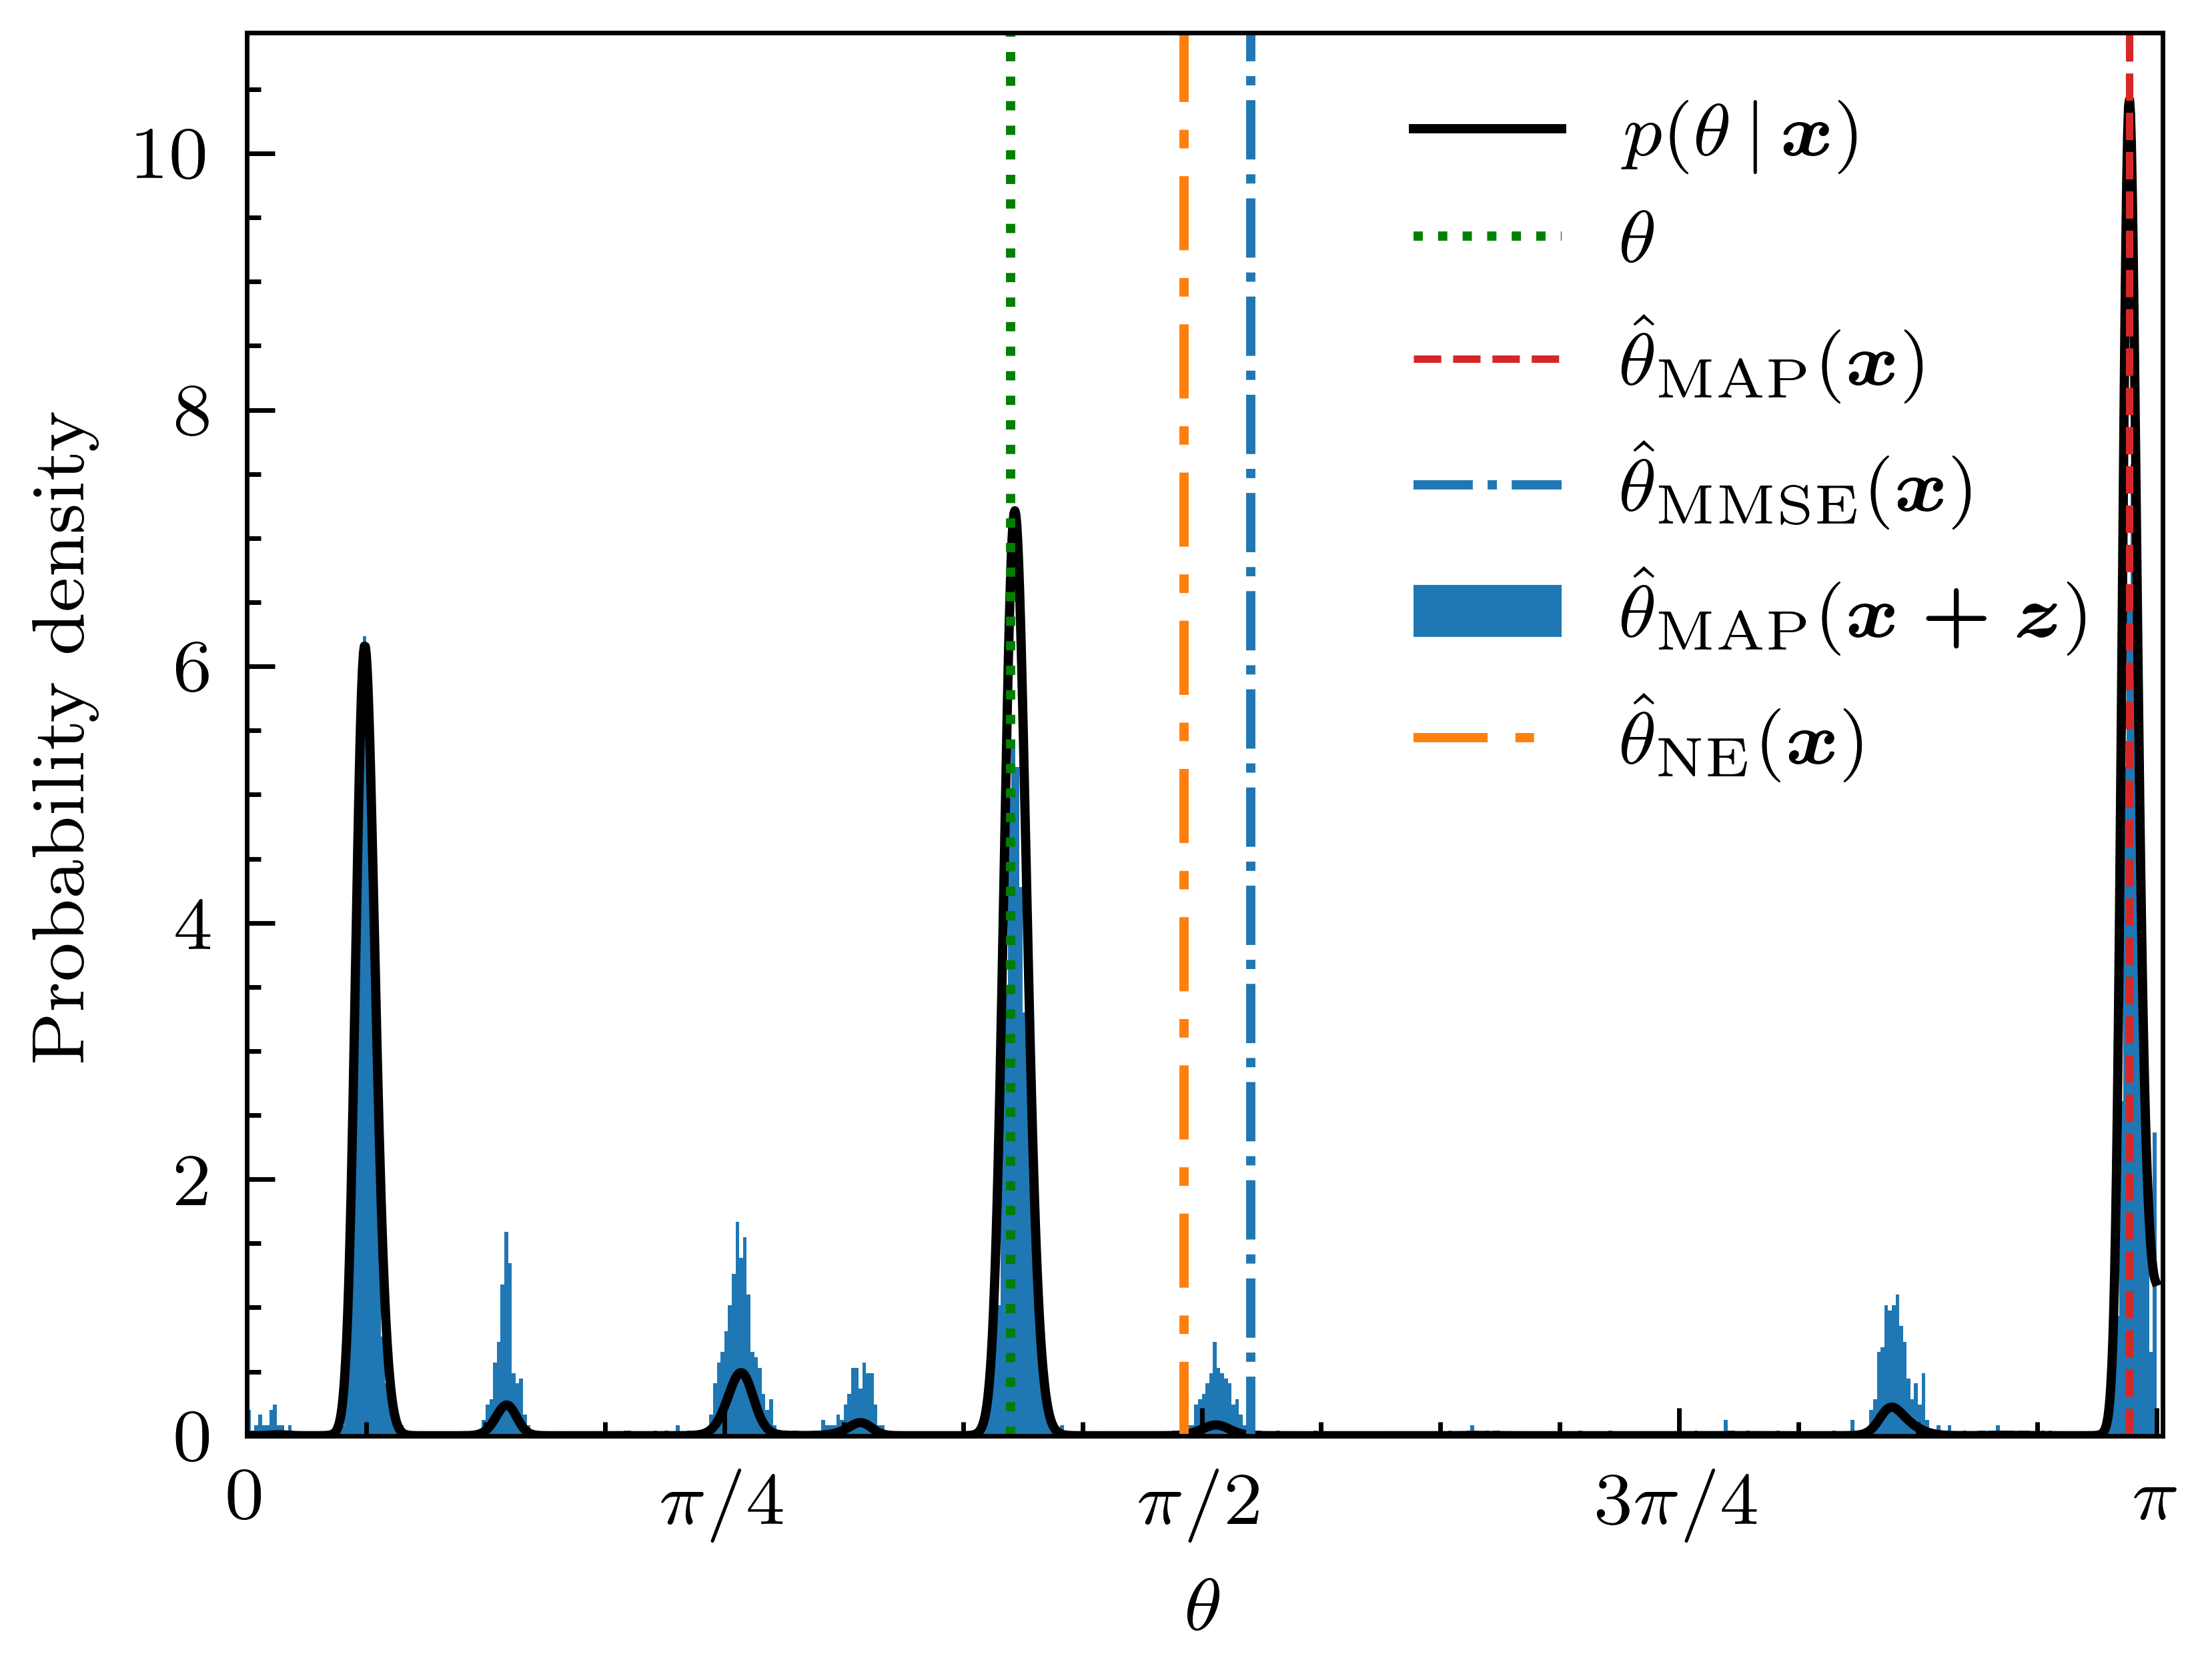

In [30]:
import math
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots

# -------------------------------------------------------------------------
# 全局学术样式配置 (SciencePlots + IEEE 规范)
# -------------------------------------------------------------------------
plt.style.use(['science', 'ieee'])
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False

# 如果开启了 usetex，确保导入 amsmath 以支持 \boldsymbol
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# 定义符合 IEEE 单栏论文的标准尺寸
FIG_SIZE = (3.3, 2.5) 
fig_a, ax_a = plt.subplots(figsize=FIG_SIZE, constrained_layout=True)

# 显式关闭网格线
ax_a.grid(False)
ax_a.tick_params(
    axis="both",
    which="both",
    top=False,
    right=False
)
# 绘制后验概率密度
ax_a.plot(phi.numpy(), post_a.numpy(),ls="-", color="k",label=r"$p(\theta\,|\,\boldsymbol{x})$")

# 绘制四条垂直线
ax_a.axvline(th_a, ls=":", c="g", lw=1, label=r"$\theta$")

ax_a.axvline(map_a, c="tab:red", ls="--", lw=0.8, label=r"$\hat\theta_{\mathrm{MAP}}(\boldsymbol{x})$")

ax_a.axvline(mmse_a, c="tab:blue", ls="-.", lw=1, label=r"$\hat\theta_{\mathrm{MMSE}}(\boldsymbol{x})$")

# 噪声增强估计 (noise-enhanced estimate, Eq. (theta_ne))
ax_a.hist(th_pert.numpy(), bins=512, range=(0.0, math.pi), density=True,
          color="tab:blue", label=r"$\hat\theta_{\mathrm{MAP}}(\boldsymbol{x+z})$")
ax_a.axvline(ne_a, c="tab:orange", ls=(0, (8, 3, 2, 3)), lw=1, label=r"$\hat\theta_{\mathrm{NE}}(\boldsymbol{x})$")
# -------------------------------------------------------------------------

# 坐标轴与刻度设置
ax_a.set(xlabel=r"$\theta$", ylabel=r"Probability density", xlim=(0, math.pi+0.01))

pi_ticks_4 = [0, math.pi/4, math.pi/2, 3*math.pi/4, math.pi]
pi_labels_4 = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']
ax_a.set_xticks(pi_ticks_4)
ax_a.set_xticklabels(pi_labels_4)
ax_a.legend(loc="upper right")
plt.show()
fig_a.savefig("Fig1.pdf", dpi=1000)   # was: D:/加权最小二乘/Fig1.pdf
fig_a.savefig("Fig1.png", dpi=300)    # quick-look raster copy